# Psychiatric Disorder Classification based on EEG
## AAI 201 Capstone Project | Belinda Mahama

This notebook builds a machine learning pipeline to classify psychiatric disorders
from EEG frequency band features, and evaluates whether model-learned feature
importances align with established neuroscientific findings.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io


url = "https://raw.githubusercontent.com/bellajelly/EEG-Psychiatric-Disorder-Project/refs/heads/main/EEG.machinelearing_data_BRMH.xlsx"

dataset = pd.read_excel(url)
print("Shape:", dataset.shape)
dataset.head()

Shape: (945, 1149)


,no.,sex,age,eeg.date,education,IQ,main.disorder,specific.disorder,AB.A.delta.a.FP1,AB.A.delta.b.FP2,...,COH.F.gamma.o.Pz.p.P4,COH.F.gamma.o.Pz.q.T6,COH.F.gamma.o.Pz.r.O1,COH.F.gamma.o.Pz.s.O2,COH.F.gamma.p.P4.q.T6,COH.F.gamma.p.P4.r.O1,COH.F.gamma.p.P4.s.O2,COH.F.gamma.q.T6.r.O1,COH.F.gamma.q.T6.s.O2,COH.F.gamma.r.O1.s.O2
0,1,M,57.0,2012.8.30,NaN,NaN,Addictive disorder,Alcohol use disorder,35.998557,21.717375,...,55.989192,16.739679,23.452271,45.678820,30.167520,16.918761,48.850427,9.422630,34.507082,28.613029
1,2,M,37.0,2012.9.6,6.0,120.0,Addictive disorder,Alcohol use disorder,13.425118,11.002916,...,45.595619,17.510824,26.777368,28.201062,57.108861,32.375401,60.351749,13.900981,57.831848,43.463261
2,3,M,32.0,2012.9.10,16.0,113.0,Addictive disorder,Alcohol use disorder,29.941780,27.544684,...,99.475453,70.654171,39.131547,69.920996,71.063644,38.534505,69.908764,27.180532,64.803155,31.485799
3,4,M,35.0,2012.10.8,18.0,126.0,Addictive disorder,Alcohol use disorder,21.496226,21.846832,...,59.986561,63.822201,36.478254,47.117006,84.658376,24.724096,50.299349,35.319695,79.822944,41.141873
4,5,M,36.0,2012.10.18,16.0,112.0,Addictive disorder,Alcohol use disorder,37.775667,33.607679,...,61.462720,59.166097,51.465531,58.635415,80.685608,62.138436,75.888749,61.003944,87.455509,70.531662


## Data Preprocessing
Loading the dataset, viewing size and shape of dataset and cleaning: dropping empty columns, imputing missing values
in education and IQ with median which is more robust to outliers than mean, and label encoding categorical variables.

In [2]:
# Check class distribution
print("Counts per disorder type")
print(dataset['main.disorder'].value_counts())

# Check missing values
print("\nMissing values per column:")
print(dataset.isnull().sum()[dataset.isnull().sum() > 0])

main.disorder
Mood disorder                         266
Addictive disorder                    186
Trauma and stress related disorder    128
Schizophrenia                         117
Anxiety disorder                      107
Healthy control                        95
Obsessive compulsive disorder          46
Name: count, dtype: int64

Missing values per column:
education        15
IQ               13
Unnamed: 122    945
dtype: int64


In [3]:
# Drop the empty unnamed column
dataset = dataset.drop(columns=[col for col in dataset.columns if 'Unnamed' in col])

# Drop columns we don't need for modeling
dataset = dataset.drop(columns=['no.', 'eeg.date'])

# Impute missing values in education and IQ with column median
dataset['education'] = dataset['education'].fillna(dataset['education'].median())
dataset['IQ'] = dataset['IQ'].fillna(dataset['IQ'].median())

# Confirm no missing values remain
print("Missing values remaining:", dataset.isnull().sum().sum())
print("Shape after cleaning:", dataset.shape)

Missing values remaining: 0
Shape after cleaning: (945, 1146)


In [22]:
from sklearn.preprocessing import LabelEncoder

# Encode the target variable
le = LabelEncoder()
dataset['disorder_label'] = le.fit_transform(dataset['main.disorder'])
print("Disorder Labels")
# See what each number maps to
for i, label in enumerate(le.classes_):
    print(f"{i}: {label}")
print('\n')
# Check what's available under mood disorder category specifically
mood_mask = dataset['main.disorder'] == 'Mood disorder'
print("Mood disorder specific disorders")
print(dataset[mood_mask]['specific.disorder'].value_counts())

Disorder Labels
0: Addictive disorder
1: Anxiety disorder
2: Healthy control
3: Mood disorder
4: Obsessive compulsive disorder
5: Schizophrenia
6: Trauma and stress related disorder


Mood disorder specific disorders
specific.disorder
Depressive disorder    199
Bipolar disorder        67
Name: count, dtype: int64


In [5]:
# One-hot encode the sex column
dataset = pd.get_dummies(dataset, columns=['sex'], drop_first=True)

# Confirm
print("Shape after encoding:", dataset.shape)
print("Sex column replaced with:", [col for col in dataset.columns if 'sex' in col])

Shape after encoding: (945, 1147)
Sex column replaced with: ['sex_M']


## Feature Importance Analysis
Extracting mean importance per EEG frequency band to evaluate alignment with
neuroscience literature predictions.

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Separate features and target
X = dataset.drop(columns=['main.disorder', 'disorder_label', 'specific.disorder'])
y = dataset['disorder_label']

# Split first - stratified to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale after splitting
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # transform only, not fit

print("Training set:", X_train_scaled.shape)
print("Test set:", X_test_scaled.shape)

Training set: (756, 1144)
Test set: (189, 1144)


## Binary Classification: Bipolar vs Depressive Disorder
I used a random forest classifier initially to train model on classifying disorder based on EEG frequency band.

Next, I subsetted the dataset to mood disorder patients only to address the clinically critical
misdiagnosis problem: misdiagnosing a patient with bipolar as unipolar depressed often leads to antidepressant administration and consequent manic episode.

PCA reduces dimensionality from 1144 to 66 components.
SMOTE generates synthetic bipolar samples to address class imbalance.

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train_scaled, y_train)

# Evaluate the model
y_pred = rf.predict(X_test_scaled)
print("Disorder Classes:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Subset to mood disorder only
mood_df = dataset[dataset['main.disorder'] == 'Mood disorder'].copy()

# Encode binary target
mood_df['bipolar_label'] = (mood_df['specific.disorder'] == 'Bipolar disorder').astype(int)
print("Mood Disorder Class distribution:")
print(mood_df['bipolar_label'].value_counts())
print("\n0 = Depressive disorder, 1 = Bipolar disorder")

# Features and target
X_mood = mood_df.drop(columns=['main.disorder', 'specific.disorder',
                                'disorder_label', 'bipolar_label'])
y_mood = mood_df['bipolar_label']

# Stratified split
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_mood, y_mood, test_size=0.2, random_state=42, stratify=y_mood)

# Scale
X_train_m_scaled = scaler.fit_transform(X_train_m)
X_test_m_scaled = scaler.transform(X_test_m)

print("\nTraining set:", X_train_m_scaled.shape)
print("Test set:", X_test_m_scaled.shape)

Disorder Classes
                                    precision    recall  f1-score   support

                Addictive disorder       0.26      0.24      0.25        37
                  Anxiety disorder       0.06      0.05      0.05        22
                   Healthy control       0.37      0.37      0.37        19
                     Mood disorder       0.29      0.30      0.29        53
     Obsessive compulsive disorder       0.10      0.11      0.11         9
                     Schizophrenia       0.15      0.13      0.14        23
Trauma and stress related disorder       0.19      0.23      0.21        26

                          accuracy                           0.23       189
                         macro avg       0.20      0.20      0.20       189
                      weighted avg       0.22      0.23      0.22       189

Mood Disorder Class distribution:
bipolar_label
0    199
1     67
Name: count, dtype: int64

0 = Depressive disorder, 1 = Bipolar disorder

Trai

## Deep Learning Comparison: MLP Classifier
Applying a multilayer perceptron with early stopping as an overfitting
prevention technique alongside tree depth constraints and cross-validation.

In [13]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)
y_pred_mlp = mlp.predict(X_test_scaled)

print("MLP Results:")
print(classification_report(y_test, y_pred_mlp,
      target_names=le.classes_))

MLP Results:
                                    precision    recall  f1-score   support

                Addictive disorder       0.27      0.27      0.27        37
                  Anxiety disorder       0.00      0.00      0.00        22
                   Healthy control       0.54      0.37      0.44        19
                     Mood disorder       0.32      0.49      0.39        53
     Obsessive compulsive disorder       0.25      0.11      0.15         9
                     Schizophrenia       0.06      0.04      0.05        23
Trauma and stress related disorder       0.14      0.08      0.10        26

                          accuracy                           0.25       189
                         macro avg       0.23      0.19      0.20       189
                      weighted avg       0.24      0.25      0.23       189



## Forest to SVM with PCA

Forest vs SVM vs PCA with SMOTE, my seconnd method for overfitting

In [29]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf',
          class_weight='balanced',
          random_state=42)

svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

print("SVM Results:")
print(classification_report(y_test, y_pred_svm,
                            target_names=le.classes_))

SVM Results:
                                    precision    recall  f1-score   support

                Addictive disorder       0.33      0.30      0.31        37
                  Anxiety disorder       0.22      0.36      0.27        22
                   Healthy control       0.29      0.42      0.34        19
                     Mood disorder       0.32      0.23      0.27        53
     Obsessive compulsive disorder       0.06      0.11      0.08         9
                     Schizophrenia       0.06      0.04      0.05        23
Trauma and stress related disorder       0.20      0.15      0.17        26

                          accuracy                           0.24       189
                         macro avg       0.21      0.23      0.21       189
                      weighted avg       0.25      0.24      0.24       189



Random Forest:
Average feature importance by frequency band:
delta    0.000958
theta    0.000925
alpha    0.000865
beta     0.000850
gamma    0.000678
dtype: float64
                     precision    recall  f1-score   support

Depressive disorder       0.74      0.97      0.84        40
   Bipolar disorder       0.00      0.00      0.00        14

           accuracy                           0.72        54
          macro avg       0.37      0.49      0.42        54
       weighted avg       0.55      0.72      0.62        54

Original features: 1144
PCA components retained: 66
Variance explained: 

SVM + PCA:
                     precision    recall  f1-score   support

Depressive disorder       0.74      0.80      0.77        40
   Bipolar disorder       0.27      0.21      0.24        14

           accuracy                           0.65        54
          macro avg       0.51      0.51      0.51        54
       weighted avg       0.62      0.65      0.63        54



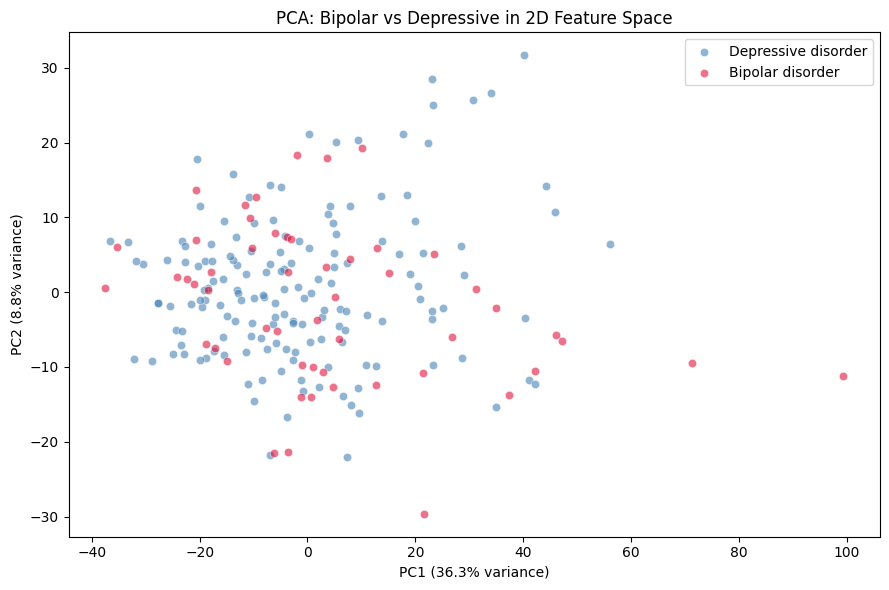

Before SMOTE: {0: 159, 1: 53}
After SMOTE: {0: 159, 1: 159}

SVM + PCA + SMOTE:
                     precision    recall  f1-score   support

Depressive disorder       0.77      0.75      0.76        40
   Bipolar disorder       0.33      0.36      0.34        14

           accuracy                           0.65        54
          macro avg       0.55      0.55      0.55        54
       weighted avg       0.66      0.65      0.65        54

Cross-validation F1 scores: [0.24383372 0.23277147 0.1614447  0.19653808 0.24043421]
Mean F1: 0.215
Standard deviation: 0.032


/tmp/ipykernel_411/2344434084.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=band_importance_series.index,


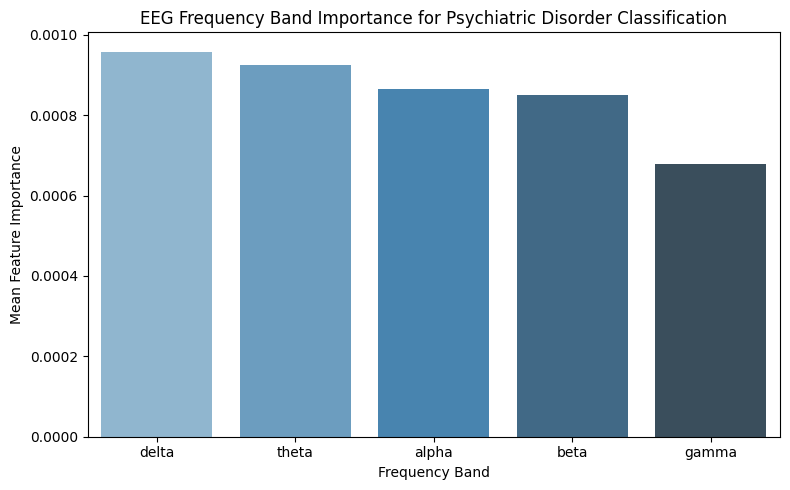

/tmp/ipykernel_411/2344434084.py:143: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=band_bipolar_series.index,


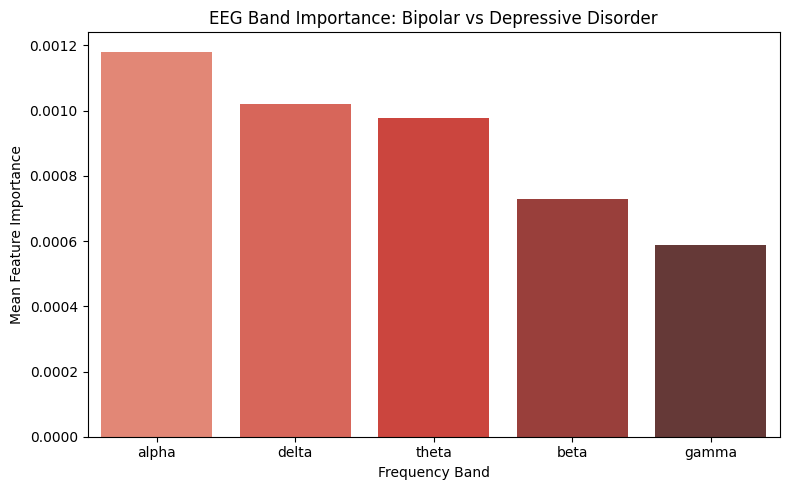

Average feature importance by frequency band:
alpha    0.001181
delta    0.001020
theta    0.000978
beta     0.000728
gamma    0.000588
dtype: float64


In [24]:
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.over_sampling import SMOTE

# Extract feature importances from Random Forest
importances = pd.Series(rf.feature_importances_, index=X.columns)

# Aggregate by frequency band
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']

band_importances = {}
for band in bands:
    # Get all columns containing the band name
    band_cols = [col for col in X.columns if band in col.lower()]
    band_importances[band] = importances[band_cols].mean()

# Convert to Series and sort
band_importance_series = pd.Series(band_importances).sort_values(ascending=False)
print("Random Forest:")
print("Average feature importance by frequency band:")
print(band_importance_series)

# Train Random Forest for bipolar vs depressive classification
rf_mood = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=3,
    class_weight='balanced',
    random_state=42
)

rf_mood.fit(X_train_m_scaled, y_train_m)
y_pred_mood = rf_mood.predict(X_test_m_scaled)

print(classification_report(y_test_m, y_pred_mood,
      target_names=['Depressive disorder', 'Bipolar disorder']))


# Consider PCA to see how many components capture majority of variance
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_m_scaled)
X_test_pca = pca.transform(X_test_m_scaled)

print(f"Original features: {X_train_m_scaled.shape[1]}")
print(f"PCA components retained: {X_train_pca.shape[1]}")
print(f"Variance explained: ")


# SVM on PCA features
svm_pca = SVC(kernel='rbf',
              class_weight='balanced',
              random_state=42)
svm_pca.fit(X_train_pca, y_train_m)
y_pred_svm_pca = svm_pca.predict(X_test_pca)

print("\nSVM + PCA:")
print(classification_report(y_test_m, y_pred_svm_pca,
      target_names=['Depressive disorder', 'Bipolar disorder']))

# Visualize first two PCA components colored by diagnosis
pca_2d = PCA(n_components=2, random_state=42)
X_mood_2d = pca_2d.fit_transform(X_train_m_scaled)

plt.figure(figsize=(9, 6))
colors = {0: 'steelblue', 1: 'crimson'}
labels = {0: 'Depressive disorder', 1: 'Bipolar disorder'}

for label in [0, 1]:
    mask = y_train_m.values == label
    plt.scatter(X_mood_2d[mask, 0],
                X_mood_2d[mask, 1],
                c=colors[label],
                label=labels[label],
                alpha=0.6,
                edgecolors='white',
                linewidth=0.5)

plt.title('PCA: Bipolar vs Depressive in 2D Feature Space')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend()
plt.tight_layout()
plt.show()

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_pca, y_train_m)

print("Before SMOTE:", y_train_m.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_train_smote).value_counts().to_dict())

# Retrain SVM on SMOTE balanced data (augmentation)
svm_smote = SVC(kernel='rbf', random_state=42)
svm_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = svm_smote.predict(X_test_pca)

print("\nSVM + PCA + SMOTE:")
print(classification_report(y_test_m, y_pred_smote,
      target_names=['Depressive disorder', 'Bipolar disorder']))


# 5-fold stratified cross-validation on the 7-class problem
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(rf, X_train_scaled, y_train,
                             cv=cv, scoring='f1_macro')

print("Cross-validation F1 scores:", cv_scores)
print(f"Mean F1: {cv_scores.mean():.3f}")
print(f"Standard deviation: {cv_scores.std():.3f}")

# Visualize feature importances across all 7 disorders
plt.figure(figsize=(8, 5))
sns.barplot(x=band_importance_series.index,
            y=band_importance_series.values,
            palette='Blues_d')
plt.title('EEG Frequency Band Importance for Psychiatric Disorder Classification')
plt.xlabel('Frequency Band')
plt.ylabel('Mean Feature Importance')
plt.tight_layout()
plt.show()

# Visualize feature importances on bipolar vs depressive disorders
rf_bipolar = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=3,
    class_weight='balanced',
    random_state=42
)
rf_bipolar.fit(X_train_m_scaled, y_train_m)

importances_bipolar = pd.Series(rf_bipolar.feature_importances_,
                                 index=X_mood.columns)
band_importances_bipolar = {}
for band in bands:
    band_cols = [col for col in X_mood.columns if band in col.lower()]
    band_importances_bipolar[band] = importances_bipolar[band_cols].mean()

band_bipolar_series = pd.Series(band_importances_bipolar).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=band_bipolar_series.index,
            y=band_bipolar_series.values,
            palette='Reds_d')
plt.title('EEG Band Importance: Bipolar vs Depressive Disorder')
plt.xlabel('Frequency Band')
plt.ylabel('Mean Feature Importance')
plt.tight_layout()
plt.show()
print("Average feature importance by frequency band:")
print(band_bipolar_series)

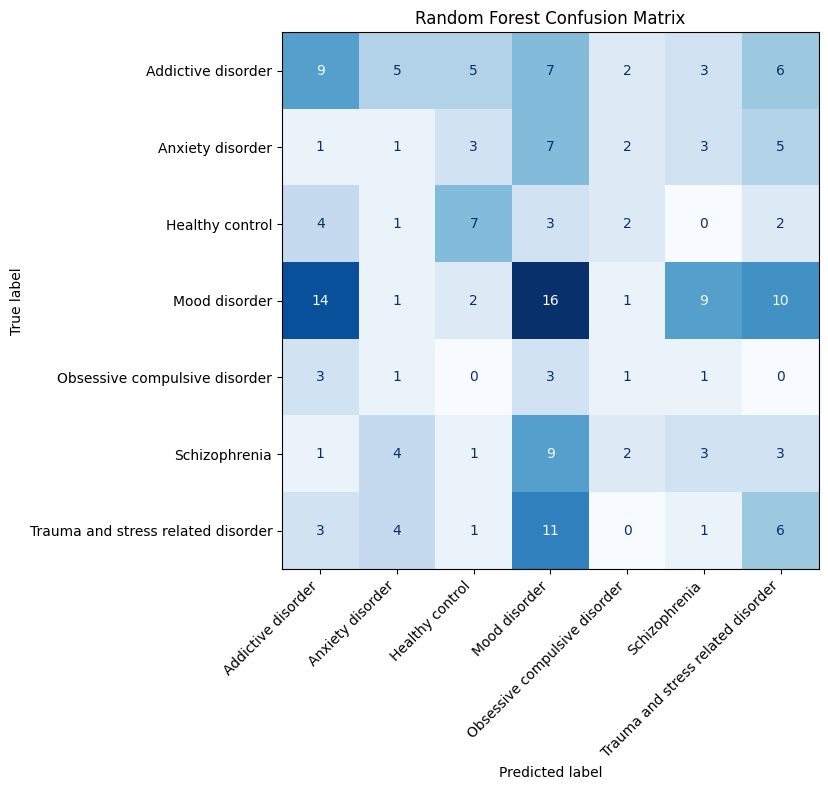

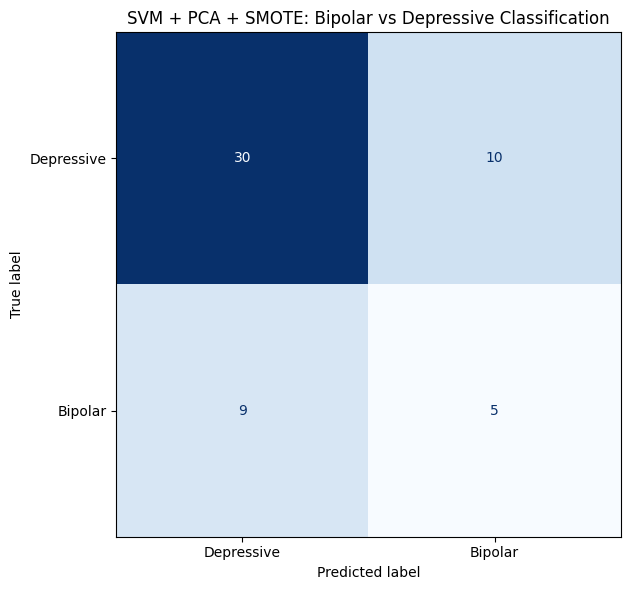

In [17]:
# Plot confusion matrix all
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Random Forest Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot confusion matrix depression vs bipolar
fig, ax = plt.subplots(figsize=(8, 6))
cm_mood = confusion_matrix(y_test_m, y_pred_smote)
disp_mood = ConfusionMatrixDisplay(confusion_matrix=cm_mood,
                                    display_labels=['Depressive', 'Bipolar'])
disp_mood.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('SVM + PCA + SMOTE: Bipolar vs Depressive Classification')
plt.tight_layout()
plt.show()

##Reflection
The most important decision in this project was isolating the mood disorder subset from the full seven-class dataset. This pivot revealed something the broader classification obscured: the frequency band hierarchy shifts when you remove other disorder categories. In the seven-class model, delta and theta dominated the EEG frequency bands, consistent with the cross-disorder low-frequency patterns documented by Newson and Thiagarajan (2019) in their review of 184 resting-state EEG studies. But when the analysis narrowed to bipolar versus depressive disorder, alpha emerged as the top feature. This aligns directly with published research: alpha sub-band activity in EEG has been investigated as a discriminative feature between major depressive disorder and bipolar disorder, with the goal of improving diagnostic accuracy in mood disorders. A separate study confirmed that patients with affective disorders of different origins display distinctive electrophysiological features in the alpha band, which could become promising biomarkers to separate bipolar depression from the recurrent type. NaturemedRxiv
The hardest challenge was model selection. Random Forest failed to learn anything meaningful about the bipolar class, predicting depressive disorder for every patient despite class weighting. Switching to SVM with PCA dimensionality reduction and SMOTE augmentation improved bipolar recall from zero to 0.36, still modest, but meaningful. The PCA scatter plot made the core problem visual: bipolar and depressive patients occupy nearly identical regions in EEG feature space, which explains both the classifier's difficulty and the nine-year median diagnostic delay these patients face in clinical practice.
The deepest lesson was about data quality and quantity. No model sophistication compensates for 53 minority class samples spread across 1144 features. The concepts learned throughout AAI 201, model selection, cross-validation, regularization, imbalance handling, dimensionality reduction, all came together here, but ultimately pointed toward the same conclusion: meaningful psychiatric classification from EEG will require larger, more carefully curated datasets before machine learning can become a reliable clinical tool for mood disorders.